# Корреляция φk (phik), χ² (хи-квадрат) и корреляция Крамера (Cramér’s V)

## 1) Что такое корреляция φk (phik)

Корреляция **φk (phik)** — это обобщённая мера зависимости между переменными, которая корректно работает не только с числовыми признаками, но и с категориальными. Она основывается на взаимной информации, но нормализует её, чтобы результат был в диапазоне **[0, 1]**, как у обычной корреляции.


## 2) Полная формула φk

Корреляция φk определяется так:
$$
\phi_k = \sqrt{\frac{\max(0,\chi^2/n - \text{bias})}{\min(k-1,r-1) - \text{bias}^*}}
$$

где:
- $\chi^2$ — статистика хи-квадрат из таблицы сопряжённости (observed vs expected),
- $n$ — количество наблюдений,
- $k$ — количество категорий переменной $X$,
- $r$ — количество категорий переменной $Y$,
- **bias** и **bias\*** — поправки для уменьшения завышения корреляции при большом количестве категорий.

Дополнительные моменты (важные для практики):
- Разбить числовые признаки на интервалы (биннинг).
- Сгладить частоты, если есть редкие категории.
- Использовать формулу, чтобы нормализовать значение в пределах $[0,1]$.


## 3) Пошаговый расчёт корреляции φk (phik)

Полный алгоритм расчёта φk для двух признаков $X$ и $Y$.

---

### Шаг 1. Подготовка данных
Для двух признаков 
 строится таблица сопряжённости

1. Если признаки **категориальные** → строим таблицу сопряжённости (частоты).
2. Если признаки **числовые** → выполняем биннинг (разбиение на интервалы), затем строим таблицу сопряжённости.
3. Если признаки смешанные → числовые бинним, категориальные оставляем как есть.

В итоге получаем таблицу частот $O_{ij}$ (observed).

---

### Шаг 2. Вычисление ожидаемых частот

Ожидаемые значения при независимости:

$$
E_{ij} = \frac{(\text{сумма по строке } i) \cdot (\text{сумма по столбцу } j)}{n}
$$

где  
$n$ — общее число наблюдений.

---

### Шаг 3. Вычисление χ² (хи-квадрат)

$$
\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}
$$

- Если наблюдаемые частоты близки к ожидаемым → χ² маленький.
- Если сильно отличаются → χ² большой.

---

### Шаг 4. Нормализация по размеру выборки (φ²)

Чтобы убрать зависимость от размера выборки:

$$
\phi^2 = \frac{\chi^2}{n}
$$

---

### Шаг 5. Вычисление поправки bias

Коррекция нужна, потому что при большом числе категорий φ² может быть положительным даже при независимости.

$$
\text{bias} = \frac{(r-1)(k-1)}{n-1}
$$

где:
- $r$ — число строк таблицы (категорий X),
- $k$ — число столбцов таблицы (категорий Y),
- $n$ — размер выборки.

Это ожидаемое значение φ² при независимости.

---

### Шаг 6. Вычисление bias*

Нормализация bias относительно максимально возможной зависимости:

$$
\text{bias}^* = \frac{\text{bias}}{\min(r-1, k-1)}
$$

---

### Шаг 7. Итоговая формула φk

$$
\phi_k =
\sqrt{
\frac{\max(0, \phi^2 - \text{bias})}
{\min(r-1, k-1) - \text{bias}^*}
}
$$

---

### Что происходит интуитивно

1. Считаем отклонение от независимости (χ²).
2. Убираем влияние размера выборки (делим на n).
3. Вычитаем ожидаемое смещение (bias).
4. Делим на максимально возможную зависимость.
5. Берём корень, чтобы получить значение в диапазоне $[0,1]$.

---

### Интерпретация

- $\phi_k \approx 0$ → признаки независимы.
- $\phi_k \approx 1$ → сильная зависимость.
- Работает для категориальных, числовых (через биннинг) и смешанных данных.
- Учитывает размерность таблицы и корректирует завышение корреляции.
  
---

## 4) Свойства φk (phik)

- Подходит для **числовых, категориальных и смешанных** данных.
- Симметрична: $\phi_k(X,Y) = \phi_k(Y,X)$.
- Корректно учитывает размерность и разное количество категорий.
- Результат в диапазоне **[0, 1]**.


## 5) Реализация φk в Python (библиотека `phik`)

Библиотека `phik` делает всё автоматически:
- строит таблицу сопряжённости,
- биннит числовые колонки (если нужно),
- считает $\chi^2$, $\phi^2$,
- применяет поправки,
- возвращает матрицу зависимостей в диапазоне $[0,1]$.

Ниже — пример кода (как мы обсуждали):


          A         B    C
A  1.000000  0.457244  1.0
B  0.457244  1.000000  1.0
C  1.000000  1.000000  1.0


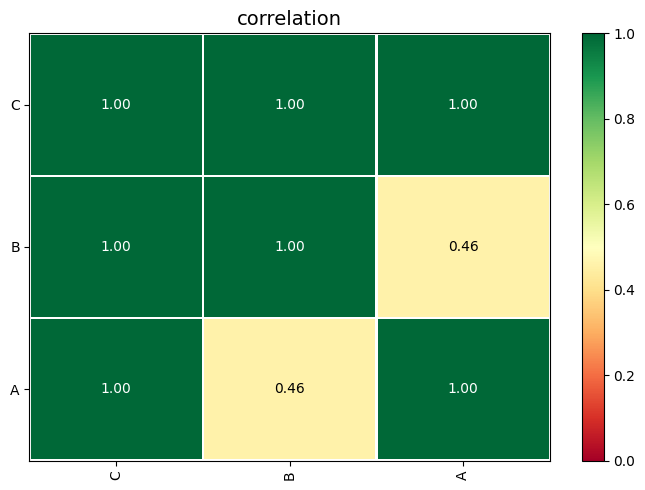

In [1]:
import pandas as pd
from phik.report import plot_correlation_matrix
from phik.phik import phik_matrix

# Пример данных
data = pd.DataFrame({
    'A': ['cat', 'dog', 'cat', 'dog', 'dog', 'cat'],
    'B': [1, 2, 1, 3, 2, 3],
    'C': [10, 15, 10, 20, 15, 25]
})

# Вычисляем матрицу phi_k
phi_k_corr = data.phik_matrix(interval_cols=['B', 'C'])
print(phi_k_corr)

# Визуализация (может открыть график в ноутбуке)
plot_correlation_matrix(
    phi_k_corr.values,
    x_labels=phi_k_corr.columns,
    y_labels=phi_k_corr.index,
    vmin=0,
    vmax=1
)

## 6) Пример расчёта φk для категориальных признаков (пошагово)

Возьмём простой пример с двумя категориальными признаками:

- **Цвет**: `['Красный', 'Красный', 'Синий', 'Синий', 'Синий', 'Зелёный']`
- **Форма**: `['Круг', 'Квадрат', 'Квадрат', 'Круг', 'Круг', 'Квадрат']`

### Шаг 1. Таблица сопряжённости (observed counts)

| Цвет \ Форма | Круг | Квадрат | Всего |
|--------------|------|---------|-------|
| Красный      | 1    | 1       | 2     |
| Синий        | 2    | 1       | 3     |
| Зелёный      | 0    | 1       | 1     |
| **Итого**    | 3    | 3       | 6     |

### Шаг 2. Ожидаемые значения (expected counts)
$$
E_{ij} = \frac{\text{сумма по строке } i \times \text{сумма по столбцу } j}{\text{общая сумма}}
$$

- Для Красный–Круг:
$$
E = \frac{2 \times 3}{6} = 1
$$
- Для Красный–Квадрат:
$$
E = \frac{2 \times 3}{6} = 1
$$
- Для Синий–Круг:
$$
E = \frac{3 \times 3}{6} = 1.5
$$
- Для Синий–Квадрат:
$$
E = \frac{3 \times 3}{6} = 1.5
$$
- Для Зелёный–Круг:
$$
E = \frac{1 \times 3}{6} = 0.5
$$
- Для Зелёный–Квадрат:
$$
E = \frac{1 \times 3}{6} = 0.5
$$

Таблица $E$:

| Цвет \ Форма | Круг | Квадрат |
|--------------|------|---------|
| Красный      | 1    | 1       |
| Синий        | 1.5  | 1.5     |
| Зелёный      | 0.5  | 0.5     |

### Шаг 3. $\chi^2$
$$
\chi^2 = \sum \frac{(O_{ij} - E_{ij})^2}{E_{ij}}
$$

Считаем по ячейкам:

- $(1-1)^2/1 = 0$
- $(1-1)^2/1 = 0$
- $(2-1.5)^2/1.5 = (0.5)^2/1.5 = 0.25/1.5 \approx 0.1667$
- $(1-1.5)^2/1.5 = (-0.5)^2/1.5 \approx 0.1667$
- $(0-0.5)^2/0.5 = (-0.5)^2/0.5 = 0.25/0.5 = 0.5$
- $(1-0.5)^2/0.5 = (0.5)^2/0.5 = 0.25/0.5 = 0.5$

Сумма:
$$
\chi^2 = 0 + 0 + 0.1667 + 0.1667 + 0.5 + 0.5 = 1.3334
$$

### Шаг 4. $\phi^2$ (phi-square)
$$
\phi^2 = \frac{\chi^2}{n} = \frac{1.3334}{6} \approx 0.2222
$$

### Шаг 5. Упрощённая оценка (как мы написали выше)
В простом приближении:
$$
\phi_k \approx \sqrt{\phi^2} = \sqrt{0.2222} \approx 0.47
$$

Это уже **значимая зависимость (почти 0.5)**.


## 7) Что такое χ² (хи-квадрат)

Хи-квадрат ($\chi^2$) — это статистическая мера, которая показывает, **насколько сильно наблюдаемые частоты отклоняются от ожидаемых частот** при предположении независимости.

### Формула
$$
\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}
$$
где:
- $O_{ij}$ — **наблюдаемое** количество в ячейке таблицы (Observed),
- $E_{ij}$ — **ожидаемое** количество при условии независимости (Expected).

### Как считается ожидаемое значение $E$
$$
E_{ij} = \frac{(\text{сумма по строке } i) \times (\text{сумма по столбцу } j)}{\text{общая сумма}}
$$

### Смысл
- Если **наблюдаемые частоты близки к ожидаемым**, $\chi^2$ будет маленьким (значит, признаки почти независимы).
- Если **наблюдаемые сильно отличаются от ожидаемых**, $\chi^2$ будет большим (есть зависимость).

### Пример (пол и курение)

Есть таблица (X — пол, Y — курение):

|          | Курит | Не курит | Всего |
|----------|-------|---------|-------|
| Мужчины  | 30    | 70      | 100   |
| Женщины  | 20    | 80      | 100   |
| **Итого**| 50    |150      | 200   |

**Ожидаемые значения**:
$$
E_{\text{муж,курит}} = \frac{100 \times 50}{200} = 25
$$
$$
E_{\text{жен,курит}} = \frac{100 \times 50}{200} = 25
$$

Дальше:
$$
\chi^2 = \frac{(30-25)^2}{25} + \frac{(70-75)^2}{75} + \frac{(20-25)^2}{25} + \frac{(80-75)^2}{75}
$$
$$
\chi^2 = \frac{25}{25} + \frac{25}{75} + \frac{25}{25} + \frac{25}{75} = 1 + 0.33 + 1 + 0.33 = 2.66
$$

**Интерпретация**: чем выше $\chi^2$, тем сильнее зависимость. Но само по себе $\chi^2$ зависит от количества наблюдений, поэтому для корреляции (как φk) его нормализуют.


## 8) Как связаны $\chi^2$ и $\phi_k$

**φk = нормализованная версия $\chi^2$, с коррекцией и адаптацией для категориальных и числовых признаков.**  

### 

1. **$\chi^2$** измеряет *отклонение наблюдаемых частот от ожидаемых* при независимости.  
   Проблемы:
   - растёт с увеличением объёма данных,
   - не ограничен сверху,
   - не учитывает количество категорий (чем больше категорий, тем выше $\chi^2$ даже при слабой зависимости).

2. **$\phi^2$ (phi-square)**:
$$
\phi^2 = \frac{\chi^2}{n}
$$
   Деление на размер выборки убирает влияние объёма данных.

3. **$\phi_k$** идёт дальше:
   - учитывает **размерность таблицы** (число категорий),
   - корректирует смещение (bias adjustment),
   - **нормализует в $[0,1]$**,
   - при необходимости делает биннинг числовых признаков.

### Формула $\phi_k$ (упрощённо)
$$
\phi_k = \sqrt{\frac{\max(0,\phi^2 - \text{bias})}{\min(r-1,k-1) - \text{bias}^*}}
$$

То есть:
- берём $\chi^2$ → считаем $\phi^2$,
- корректируем на смещение,
- делим на максимально возможную зависимость для этой таблицы,
- берём корень, чтобы получить диапазон $[0,1]$.

Итог:
- **$\phi_k$ = $\chi^2$, приведённый к интерпретируемой шкале**.
- При независимости → $\phi_k \approx 0$,
- При идеальной зависимости → $\phi_k \approx 1$.


## 9) Корреляция Крамера (Cramér’s V)

**Корреляция Крамера (Cramér’s V)** — это нормализованная версия $\chi^2$, которая даёт значение в диапазоне **$[0, 1]$** и показывает силу связи между двумя категориальными признаками.

### Формула
$$
V = \sqrt{\frac{\chi^2}{n \cdot (k-1)}}
$$

где:
- $\chi^2$ — статистика хи-квадрат (сумма $(O_{ij} - E_{ij})^2 / E_{ij}$),
- $n$ — количество наблюдений,
- $k-1$ — минимальное из (число строк - 1, число столбцов - 1), то есть фактически $\min(r-1, k-1)$.

### Интерпретация
- $V = 0$ → признаки независимы,
- $V = 1$ → идеальная зависимость,
- Чем ближе к 1, тем сильнее связь.

### Особенности
- Только для **категориальных признаков**.
- **Не учитывает** смещение при большом числе категорий → может завышать значения.
- Не подходит для числовых признаков напрямую.

### Пример расчёта (на нашей таблице)
Ранее мы посчитали:
$$
\chi^2 = 1.3334,\; n = 6,\; \min(r-1,k-1) = \min(3-1, 2-1) = 1
$$

Подставляем:
$$
V = \sqrt{\frac{1.3334}{6 \cdot 1}} = \sqrt{0.2222} \approx 0.47
$$

То есть Cramér’s V $\approx 0.47$ (как и φk в нашем упрощённом варианте).

Но φk скорректировал бы смещение если бы категорий было много.


In [2]:
import numpy as np
import pandas as pd

def cramers_v_from_contingency(contingency: pd.DataFrame) -> float:
    """Cramér’s V для таблицы сопряжённости (категориальные признаки)."""
    observed = contingency.values.astype(float)
    n = observed.sum()
    row_sums = observed.sum(axis=1, keepdims=True)
    col_sums = observed.sum(axis=0, keepdims=True)
    expected = row_sums @ col_sums / n

    # chi-square
    chi2 = np.nansum((observed - expected) ** 2 / expected)

    r, k = observed.shape
    denom = n * (min(r - 1, k - 1))
    if denom <= 0:
        return np.nan
    return float(np.sqrt(chi2 / denom))

# Таблица из примера
cont = pd.DataFrame(
    [[1, 1],
     [2, 1],
     [0, 1]],
    index=['Красный', 'Синий', 'Зелёный'],
    columns=['Круг', 'Квадрат']
)

print('Таблица сопряжённости:\n', cont, sep='')
print('Cramér’s V =', cramers_v_from_contingency(cont))


Таблица сопряжённости:
         Круг  Квадрат
Красный     1        1
Синий       2        1
Зелёный     0        1
Cramér’s V = 0.4714045207910317


## 10) Как рассчитываются поправки bias и bias\*

Эти поправки нужны, чтобы **не завышать корреляцию при большом числе категорий** (классическая проблема Cramér’s V).  

### Зачем нужны поправки
- При большом числе категорий или пустых ячеек таблицы сопряжённости $\chi^2$ растёт даже при независимости.
- Без коррекции φk будет показывать ложную зависимость.
- **bias** и **bias\*** уменьшают этот эффект, чтобы $\phi_k \to 0$ при независимости.

### Формулы (как мы записали выше)

#### 1) bias
$$
\text{bias} = \frac{(r-1)(k-1)}{n-1}
$$
где:
- $r$ — количество строк (категорий первой переменной),
- $k$ — количество столбцов (категорий второй переменной),
- $n$ — количество наблюдений.

Это **ожидаемое значение $\phi^2$** при независимости, чтобы вычесть его.

#### 2) bias\*
$$
\text{bias}^* = \frac{\text{bias}}{\min(r-1, k-1)}
$$

Это нормализация bias относительно максимально возможного $\phi^2$, чтобы корректно делить в формуле φk.

### Формула φk с поправками
$$
\phi_k = \sqrt{\frac{\max(0,\phi^2 - \text{bias})}{\min(r-1,k-1) - \text{bias}^*}}
$$
где
$$
\phi^2 = \frac{\chi^2}{n}
$$

### Пример расчёта поправок
Возьмём наш пример:
- $r = 3$, $k = 2$, $n = 6$

bias:
$$
\text{bias} = \frac{(3-1)(2-1)}{6-1} = \frac{2 \cdot 1}{5} = 0.4
$$

bias\*:
$$
\text{bias}^* = \frac{0.4}{\min(2,1)} = 0.4
$$

$\phi^2 = \chi^2/n = 1.3334/6 \approx 0.2222$

Теперь:
$$
\phi_k = \sqrt{\frac{\max(0,0.2222 - 0.4)}{1 - 0.4}} = \sqrt{\frac{0}{0.6}} = 0
$$

👉 $\phi_k = 0$, что логично, потому что при такой маленькой выборке и редких категориях зависимость статистически незначима.


## 11) Сравнение χ² vs Cramér’s V vs φk

| Характеристика           | **χ² (Chi-square)**                 | **Cramér’s V**                           | **φk (Phik)**                              |
|--------------------------|--------------------------------------|-------------------------------------------|---------------------------------------------|
| **Диапазон значений**    | $[0, \infty)$                       | $[0, 1]$                                  | $[0, 1]$                                    |
| **Зависимость от размера выборки** | Сильно зависит (чем больше выборка, тем выше χ²) | Минимальная зависимость                   | Минимальная зависимость                     |
| **Нормализация**         | Нет                                  | Да (делит χ² на $n$ и нормализует по $\min(k-1, r-1)$) | Да, с учётом таблицы и поправок             |
| **Корректность для больших таблиц** | Плохо работает (значения огромные) | Лучше, но завышает при большом числе категорий | Исправлено (bias adjustment)               |
| **Интерпретация**        | Чем больше, тем сильнее связь, но без верхней границы | 0 = независимость, 1 = идеальная зависимость | 0 = независимость, 1 = идеальная зависимость |
| **Категориальные признаки** | Да                                 | Да                                        | Да                                          |
| **Числовые признаки**    | Нет                                  | Нет                                       | Да (через автоматический биннинг)           |
| **Смешанные признаки**   | Нет                                  | Нет                                       | Да                                          |
| **Монотонная / нелинейная зависимость** | Не применимо                 | Не применимо                              | Можно оценивать даже при нелинейной зависимости |

### Где использовать
- **χ²** — для статистических тестов (проверка независимости), но плохо как мера силы связи.
- **Cramér’s V** — если только категориальные признаки и небольшое число категорий.
- **φk** — универсальный вариант: работает для **числовых, категориальных, смешанных** признаков, корректирует смещение, результат в $[0,1]$.


In [3]:
import numpy as np
import pandas as pd

def chi2_from_contingency(contingency: pd.DataFrame) -> float:
    observed = contingency.values.astype(float)
    n = observed.sum()
    row_sums = observed.sum(axis=1, keepdims=True)
    col_sums = observed.sum(axis=0, keepdims=True)
    expected = row_sums @ col_sums / n
    return float(np.nansum((observed - expected) ** 2 / expected))

def phik_bias_and_phik(contingency: pd.DataFrame) -> tuple[float, float, float, float]:
    """Упрощённая иллюстрация вычисления bias, bias*, φ² и φk по тем формулам, что мы обсудили."""
    observed = contingency.values.astype(float)
    n = observed.sum()
    r, k = observed.shape

    chi2 = chi2_from_contingency(contingency)
    phi2 = chi2 / n

    # bias и bias* как в нашем обсуждении
    bias = ((r - 1) * (k - 1)) / (n - 1) if n > 1 else np.nan
    m = min(r - 1, k - 1)
    bias_star = bias / m if m > 0 else np.nan

    numerator = max(0.0, phi2 - bias)
    denom = (m - bias_star) if (m - bias_star) > 0 else np.nan
    phik = float(np.sqrt(numerator / denom)) if denom == denom else np.nan  # denom==denom: проверка на NaN

    return float(bias), float(bias_star), float(phi2), phik

cont = pd.DataFrame(
    [[1, 1],
     [2, 1],
     [0, 1]],
    index=['Красный', 'Синий', 'Зелёный'],
    columns=['Круг', 'Квадрат']
)

bias, bias_star, phi2, phik_val = phik_bias_and_phik(cont)
print('bias      =', bias)
print('bias*     =', bias_star)
print('phi^2     =', phi2)
print('phi_k     =', phik_val)


bias      = 0.4
bias*     = 0.4
phi^2     = 0.2222222222222222
phi_k     = 0.0
